In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50, MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## CARGA Y EXPLORACIÓN DE LOS DATOS

In [4]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

In [5]:
print("Tamaño del conjunto de entrenamiento:", x_train.shape)
print("Tamaño del conjunto de prueba:", x_test.shape)
print("Número de clases:", len(np.unique(y_train)))

Tamaño del conjunto de entrenamiento: (50000, 32, 32, 3)
Tamaño del conjunto de prueba: (10000, 32, 32, 3)
Número de clases: 100


In [6]:
class_names = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'computer_keyboard',
    'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain',
    'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree',
    'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket',
    'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor',
    'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

C:\Users\pere_\AppData\Local\Temp\ipykernel_18428\3955223726.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


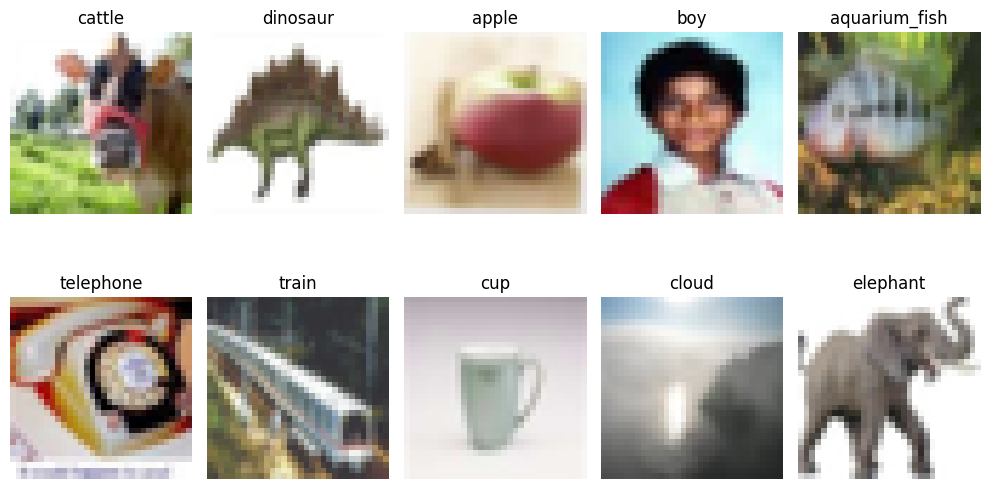

In [7]:
plt.figure(figsize=(10, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis('off')
plt.tight_layout()

## PREPROCESAMIENTO

In [8]:
# Normalizar los valores de píxeles a rango [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [9]:
# Codificación one-hot de las etiquetas
num_classes = 100
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

In [10]:
print("Forma de y_train después del one-hot encoding:", y_train_cat.shape)

Forma de y_train después del one-hot encoding: (50000, 100)


In [11]:
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train, y_train_cat, test_size=0.1, random_state=42, stratify=y_train
)

In [12]:
print("Train:", x_train_final.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

Train: (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Test: (10000, 32, 32, 3)


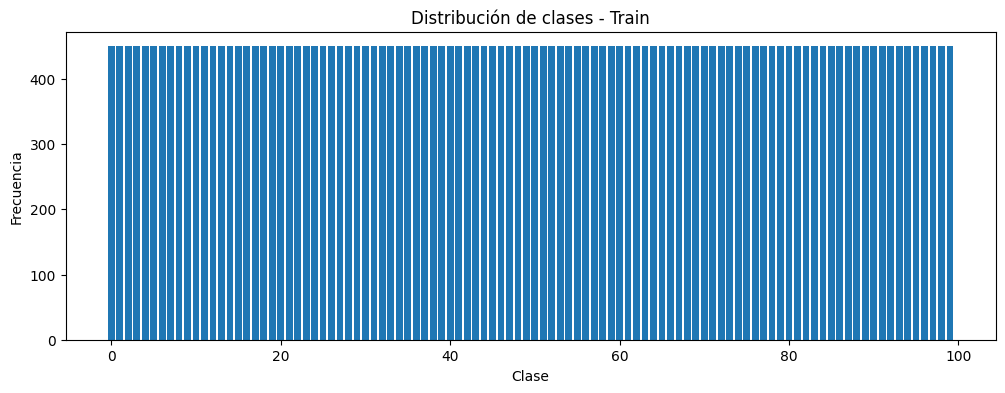

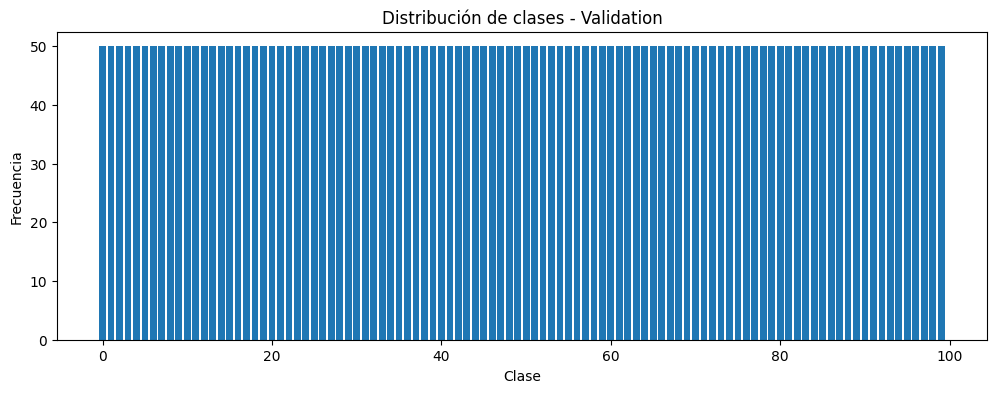

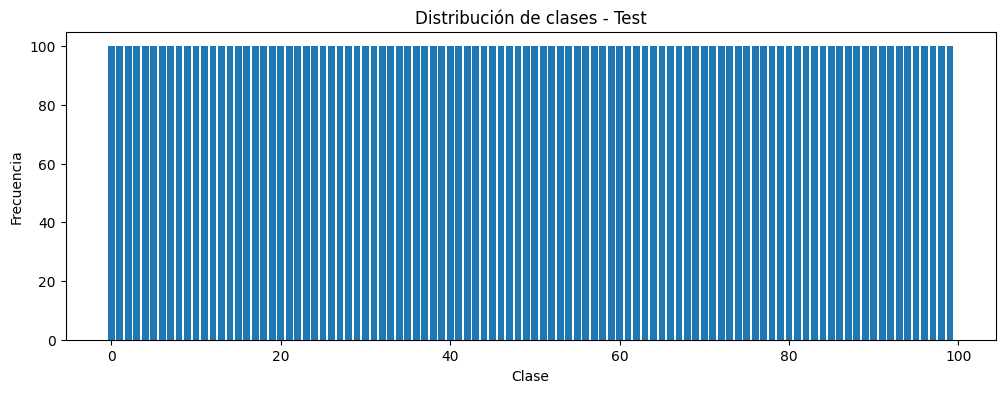

In [13]:
# Visualizar la distribución de clases
def plot_class_distribution(y, title):
    labels = np.argmax(y, axis=1)
    counts = np.bincount(labels)
    plt.figure(figsize=(12, 4))
    plt.bar(range(100), counts)
    plt.title(title)
    plt.xlabel("Clase")
    plt.ylabel("Frecuencia")
    plt.show()

plot_class_distribution(y_train_final, "Distribución de clases - Train")
plot_class_distribution(y_val, "Distribución de clases - Validation")
plot_class_distribution(y_test_cat, "Distribución de clases - Test")

## ESTRATEGIA 1: MODELOS PREENTRENADOS

### PREPARACIÓN DE LOS MODELOS

In [14]:
def resize_in_batches(x, img_size=96, batch_size=1000):
    resized = []
    for i in range(0, len(x), batch_size):
        batch = tf.image.resize(x[i:i+batch_size], [img_size, img_size])
        resized.append(batch.numpy())
    return np.concatenate(resized, axis=0)

In [15]:
IMG_SIZE = 96

x_train_resized = resize_in_batches(x_train_final, IMG_SIZE)
x_val_resized = resize_in_batches(x_val, IMG_SIZE)
x_test_resized = resize_in_batches(x_test, IMG_SIZE)

In [16]:
print("x_train_resized:", x_train_resized.shape)
print("x_val_resized:", x_val_resized.shape)
print("x_test_resized:", x_test_resized.shape)

x_train_resized: (45000, 96, 96, 3)
x_val_resized: (5000, 96, 96, 3)
x_test_resized: (10000, 96, 96, 3)


In [20]:
# Aplicar Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)

# Generador solo para entrenamiento
train_generator = train_datagen.flow(x_train_resized, y_train_final, batch_size=64)


In [22]:
# Función Transfer Learning
def build_transfer_model(base_model_class, input_shape=(IMG_SIZE, IMG_SIZE, 3), fine_tune_at=None):
    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Congelar todas las capas si no se especifica fine_tune
    if fine_tune_at is None:
        base_model.trainable = False
    else:
        base_model.trainable = True
        for layer in base_model.layers[:fine_tune_at]:
            layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(100, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

### ESTRUCTURA ResNet50

In [ ]:
# Construir el modelo con ResNet50
model_resnet = build_transfer_model(ResNet50, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Callbacks
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(patience=2, factor=0.5, monitor='val_accuracy')
]

# Entrenar el modelo
history_resnet = model_resnet.fit(
    train_generator,
    epochs=30,
    validation_data=(x_val_resized, y_val),
    callbacks=callbacks
)


Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 1040s 1s/step - accuracy: 0.0415 - loss: 4.4230 - val_accuracy: 0.1182 - val_loss: 4.0699
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 1563s 2s/step - accuracy: 0.0859 - loss: 4.1290 - val_accuracy: 0.1400 - val_loss: 3.8938
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 1559s 2s/step - accuracy: 0.0942 - loss: 4.0744 - val_accuracy: 0.1392 - val_loss: 3.8509
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 863s 1s/step - accuracy: 0.0973 - loss: 4.0472 - val_accuracy: 0.1500 - val_loss: 3.8168
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 605s 860ms/step - accuracy: 0.1015 - loss: 4.0418 - val_accuracy: 0.1536 - val_loss: 3.8062
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 602s 854ms/step - accuracy: 0.0998 - loss: 4.0229 - val_accuracy: 0.1602 - val_loss: 3.7984
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 603s 857ms/step - accuracy: 0.1013 - loss: 4.0239 - val_accuracy: 0.1564 - val_loss: 3.7866
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 650s 923ms/step - accuracy: 0.1007 - loss: 4.

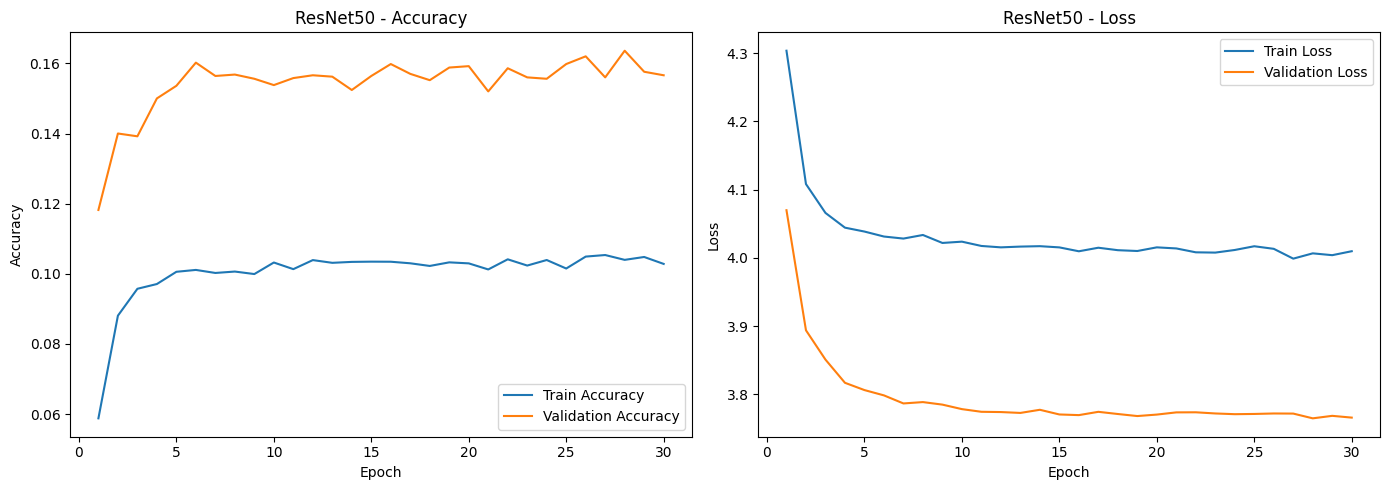

In [29]:
def plot_training_history(history, model_name="Modelo"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Usarlo con tu historial de entrenamiento
plot_training_history(history_resnet, model_name="ResNet50")

Accuracy:
La validación es consistentemente más alta que el entrenamiento → ¡Eso es buena señal!

Aunque no sube mucho (~0.16 máx en validación), es un comienzo sólido sin fine-tuning.

Loss:
La pérdida baja bien al inicio pero se estabiliza después de unas 10 epochs.

No parece haber overfitting fuerte, lo cual también es bueno.

In [ ]:
# Reconstruir el modelo manteniendo base_model accesible

In [52]:


# Tamaño de entrada
IMG_SIZE = 96
input_shape = (IMG_SIZE, IMG_SIZE, 3)

# Entrada del modelo
inputs = Input(shape=input_shape)

# Modelo base
base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=inputs)

# Congelar todo inicialmente
base_model.trainable = False

# Capas superiores personalizadas
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(100, activation='softmax')(x)

# Modelo final
model_resnet = Model(inputs=inputs, outputs=outputs)

# Compilar
model_resnet.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

print("Modelo reconstruido con base_model separado ✅")


Modelo reconstruido con base_model separado ✅


In [44]:
history_resnet = model_resnet.fit(
    train_generator,
    epochs=30,
    validation_data=(x_val_resized, y_val),
    callbacks=callbacks
)


Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 839s 1s/step - accuracy: 0.0311 - loss: 5.4085 - val_accuracy: 0.0762 - val_loss: 4.2746 - learning_rate: 1.0000e-05
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 848s 1s/step - accuracy: 0.0677 - loss: 4.6739 - val_accuracy: 0.1160 - val_loss: 4.0514 - learning_rate: 1.0000e-05
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 892s 1s/step - accuracy: 0.0879 - loss: 4.4295 - val_accuracy: 0.1314 - val_loss: 3.9186 - learning_rate: 1.0000e-05
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 863s 1s/step - accuracy: 0.1041 - loss: 4.2757 - val_accuracy: 0.1248 - val_loss: 3.9623 - learning_rate: 1.0000e-05
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 841s 1s/step - accuracy: 0.1173 - loss: 4.1552 - val_accuracy: 0.0974 - val_loss: 4.7884 - learning_rate: 1.0000e-05
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 850s 1s/step - accuracy: 0.1292 - loss: 4.0531 - val_accuracy: 0.1892 - val_loss: 3.6147 - learning_rate: 5.0000e-06
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 849s 1s/step - acc

#### FINE-TUNING

In [45]:
# Descongelar las últimas 30 capas del modelo base
fine_tune_at = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

print(f"Descongeladas las últimas {len(base_model.layers) - fine_tune_at} capas.")

# Recompilar con tasa de aprendizaje más baja
model_resnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Descongeladas las últimas 30 capas.


In [46]:
fine_tune_epochs = 10
total_epochs = 30 + fine_tune_epochs

history_finetune = model_resnet.fit(
    train_generator,
    epochs=total_epochs,
    initial_epoch=30,
    validation_data=(x_val_resized, y_val),
    callbacks=callbacks
)


Epoch 31/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 877s 1s/step - accuracy: 0.1843 - loss: 3.6356 - val_accuracy: 0.1676 - val_loss: 3.9846 - learning_rate: 1.0000e-05
Epoch 32/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 867s 1s/step - accuracy: 0.1842 - loss: 3.6643 - val_accuracy: 0.1410 - val_loss: 4.1801 - learning_rate: 1.0000e-05
Epoch 33/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 880s 1s/step - accuracy: 0.1824 - loss: 3.6496 - val_accuracy: 0.1718 - val_loss: 3.8513 - learning_rate: 1.0000e-05
Epoch 34/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 949s 1s/step - accuracy: 0.1944 - loss: 3.5925 - val_accuracy: 0.1554 - val_loss: 3.9136 - learning_rate: 1.0000e-05
Epoch 35/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 953s 1s/step - accuracy: 0.1916 - loss: 3.5957 - val_accuracy: 0.1986 - val_loss: 3.5846 - learning_rate: 1.0000e-05
Epoch 36/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 933s 1s/step - accuracy: 0.1962 - loss: 3.5650 - val_accuracy: 0.1892 - val_loss: 3.6078 - learning_rate: 1.0000e-05
Epoch 37/40
704/704 ━━━━━━━━━━━━━━━━━━━━ 924s 1s/ste

In [47]:
def combine_histories(h1, h2):
    history = {}
    for key in h1.history.keys():
        history[key] = h1.history[key] + h2.history[key]
    return history


In [48]:
def plot_training_history(history_dict, model_name="Modelo"):
    acc = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']
    loss = history_dict['loss']
    val_loss = history_dict['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.axvline(x=len(acc) - len(history_finetune.history['loss']), color='gray', linestyle='--', label='Fine-Tune Start')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.axvline(x=len(acc) - len(history_finetune.history['loss']), color='gray', linestyle='--', label='Fine-Tune Start')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


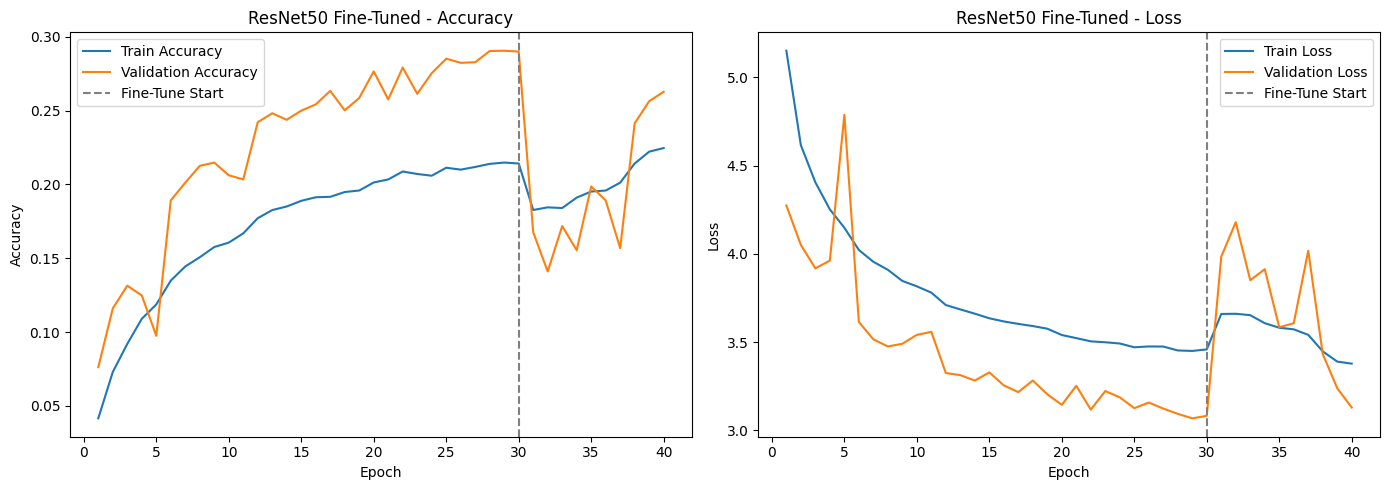

In [49]:
# Combinar los historiales
full_history_dict = combine_histories(history_resnet, history_finetune)

# Graficar
plot_training_history(full_history_dict, model_name="ResNet50 Fine-Tuned")


La precisión de validación pasó de ~16% a casi 30% después del fine-tuning.

El modelo aprende mejor cuando descongelamos capas profundas.

La pérdida siguió bajando, y aunque hay algo de ruido después del fine-tuning (normal en validación), la tendencia es positiva.

No hay señales graves de overfitting

### AVALUACIÓN FINAL CONJUNTO TEST

In [50]:
test_loss, test_accuracy = model_resnet.evaluate(x_test_resized, y_test_cat, verbose=1)
print(f"\n🎯 Test Accuracy (ResNet50 Fine-Tuned): {test_accuracy:.4f}")
print(f"🧮 Test Loss: {test_loss:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 118s 373ms/step - accuracy: 0.2649 - loss: 3.1054

🎯 Test Accuracy (ResNet50 Fine-Tuned): 0.2661
🧮 Test Loss: 3.1381


In [51]:
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Accuracy: 0.2661


Modelo	            Train Accuracy	Val Accuracy	Test Accuracy	      Observaciones
ResNet50 (congelado)	~10.5%	       ~16%	            ~16 %	       Buen punto de partida, sin fine-tuning
ResNet50 (fine-tuned)	~22–23%	     ~28–29%	        26,6 %	       Mejora tras descpngelar capas